1. DATA CLEANING
   -Checking and Removing Missing and duplicated values
   -drop irrelevant columns
   -rename columns
   -Converting the target variable into binary(Label Encoder)
2. EDA
   -value counts visualise
   -creating num_char,num_words,num_sentences from text data
   -understanding and visualising how num_char,num_words,num_sentences vary across spam and not spam data
   -correlation and heatmap
3. TEXT PREPROCESSING
   -clean text(lower case, tokenize, remove special chars,remove stopwords remove punctuations, stemming) to create transformed text
   -word clout visualise and code to find the most occured word in spam and ham messages
4.MODEL BUILDING
   -Text Vectorization using BoW(Count Vectorize) and TfIdf
   -Naive Bayes(Guassian,Multinomial,Bernoulli)

IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df=pd.read_csv('spam.csv', encoding="latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
df.shape

(5572, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

DATA CLEANING

In [8]:
df.dropna(axis=1,inplace=True)

In [9]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.describe()

,v1,v2
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df.duplicated().sum()

403

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [15]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
lb=LabelEncoder()

In [18]:
df['target']=lb.fit_transform(df['target'])

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [21]:
df.duplicated().sum()

0

In [22]:
df.shape

(5169, 2)

EDA

In [23]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [25]:
(df['target'].value_counts()/len(df['target']))*100

target
0    87.366996
1    12.633004
Name: count, dtype: float64

<Axes: xlabel='target', ylabel='count'>

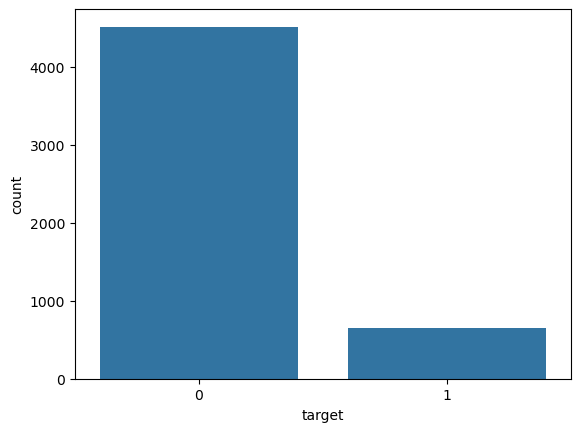

In [26]:
sns.countplot(data=df,x='target')

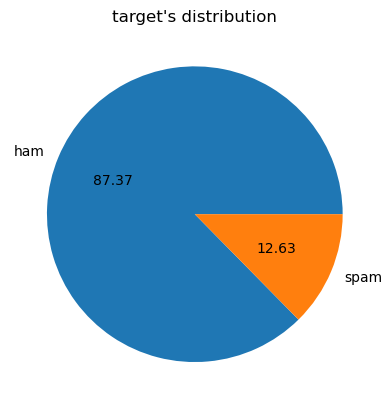

In [27]:
plt.pie(x=df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.title("target's distribution")
plt.show()

In [28]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [29]:
s='jfnj ncdfmnck,ndrjknvl jndxk'
len(s)

28

In [30]:
df['num_char']=df['text'].apply(lambda x:len(x))

In [31]:
import nltk

In [32]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Priya
[nltk_data]     Gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Priya
[nltk_data]     Gupta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [34]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [35]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [36]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [37]:
df.groupby('target').mean(numeric_only=True)

,num_char,num_words,num_sentences
target,,,
0,70.459256,17.123782,1.820195
1,137.891271,27.667688,2.970904


In [38]:
df.describe()[['num_char','num_words','num_sentences']]

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [39]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


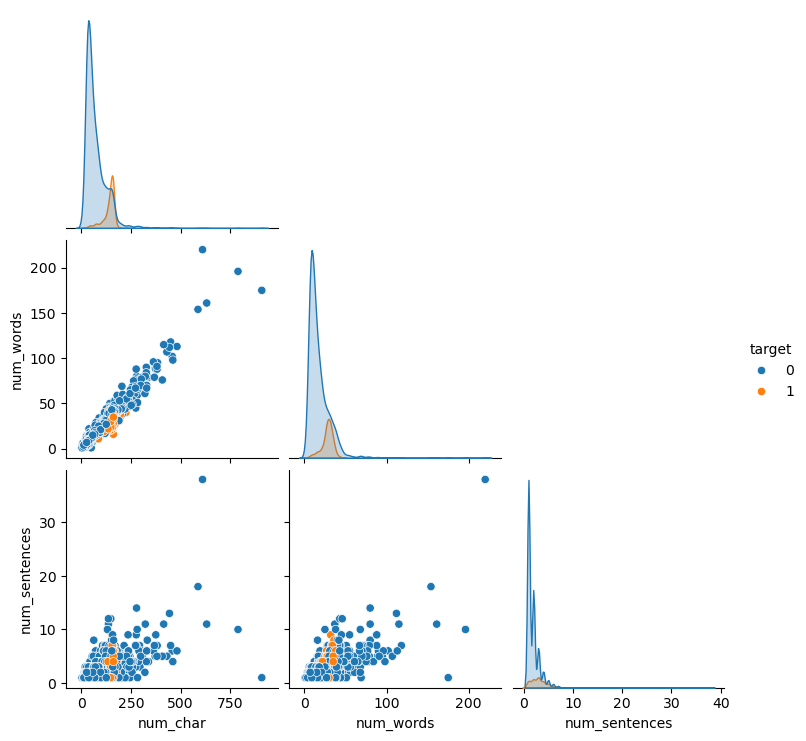

In [40]:
sns.pairplot(df,hue='target',corner=True)

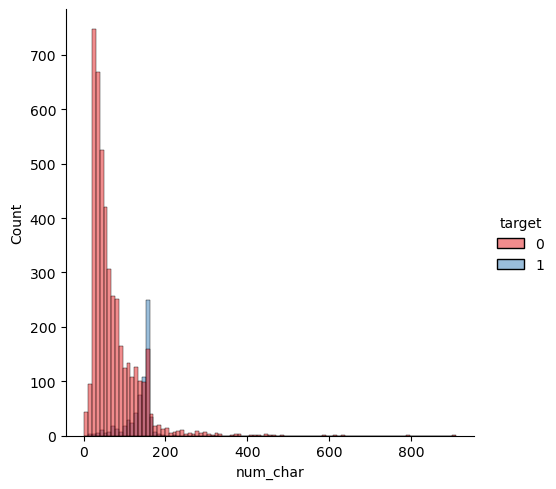

In [41]:
sns.displot(data=df,x='num_char',hue='target',palette='Set1')

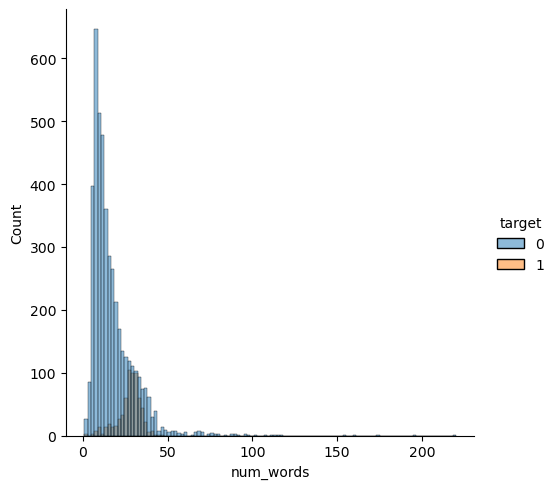

In [42]:
sns.displot(data=df,x='num_words',hue='target')

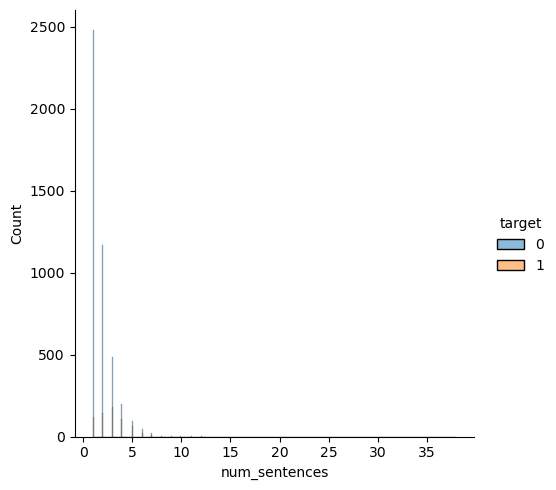

In [43]:
sns.displot(data=df,x='num_sentences',hue='target')

In [44]:
df.corr(numeric_only=True)

,target,num_char,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

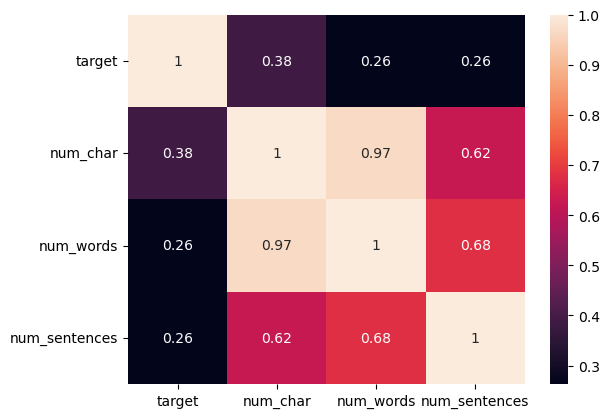

In [45]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#here we can observe high multicollinearity(num_char highly correlated with num_words and num_char correlated with num_sentences)
#makes sense to keep only 1 input
#we'll choose num_char as its influencing the target most

TEXT PREPROCESSING

In [46]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [47]:
def clean_text(text):
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.stem import PorterStemmer
    from nltk.corpus import stopwords
    import string

    #lower case
    text=text.lower()
    #tokenising
    text=word_tokenize(text)
    #remove special chars
    text=[i for i in text if i.isalnum()==True]
    #remove stopwords
    #stopwords=stopwords.words('english')
    #text=[i for i in text if i not in stopwords]
    #remove punctuations
    p=string.punctuation
    text=[i for i in text if i not in p]
    #stemming
    #ps=PorterStemmer()
    #text=[ps.stem(i) for i in text]
    return " ".join(text)

In [48]:
df['transformed_text']=df['text'].apply(clean_text)

In [49]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goes to usf he lives around ...


In [50]:
#word cloud to visualise which words occur more in spam text

In [51]:
!pip install wordcloud

In [52]:
from wordcloud import WordCloud

In [53]:
wc=WordCloud()

In [54]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

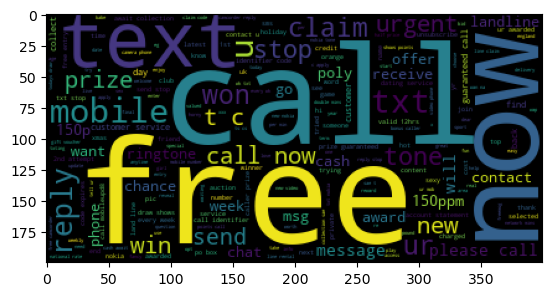

In [55]:
plt.imshow(spam_wc)

In [56]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

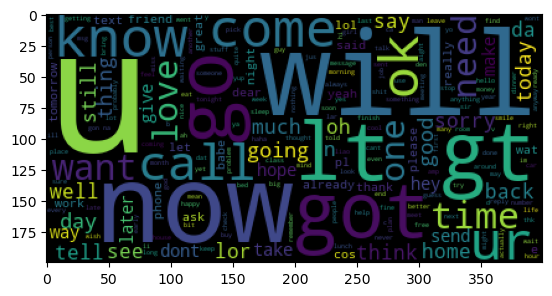

In [57]:
plt.imshow(ham_wc)

In [58]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [59]:
len(spam_corpus)

14475

In [60]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('to', 595),
 ('a', 330),
 ('call', 302),
 ('you', 267),
 ('your', 241),
 ('free', 191),
 ('for', 183),
 ('the', 183),
 ('now', 164),
 ('or', 157),
 ('2', 155),
 ('is', 144),
 ('txt', 130),
 ('from', 122),
 ('on', 121),
 ('u', 119),
 ('ur', 119),
 ('have', 116),
 ('mobile', 105),
 ('text', 104),
 ('and', 104),
 ('stop', 104),
 ('4', 97),
 ('claim', 96),
 ('reply', 96),
 ('with', 94),
 ('this', 82),
 ('prize', 81),
 ('of', 81),
 ('our', 77)]

MODEL BUILDING AND EVALUATION

In [61]:
#Text Vectorization using TFIDF
#not doing stemming gives slightly better results-not doing stemming

In [62]:
df.shape

(5169, 6)

In [63]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goes to usf he lives around ...


In [64]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV,GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import precision_recall_curve,precision_score,recall_score,auc,f1_score

In [65]:
x=df['transformed_text'].values
y=df['target'].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42)

In [66]:
tfidf = TfidfVectorizer()

In [67]:
#logistic regression

In [68]:
pipeline_lr=ImbPipeline([('tfidf',tfidf),('smote',"passthrough"),('lr',LogisticRegression(max_iter=5000))])

In [69]:
params_lr={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],'smote':[SMOTE(),'passthrough'],
           'lr__penalty':['l1','l2'],'lr__class_weight':[None,'balanced'],'lr__C':[0.01,0.1,1,10],'lr__solver':['lbfgs', 'liblinear', 'newton-cg', 'saga']}

In [70]:
cv=StratifiedKFold(n_splits=10, shuffle=True)

In [71]:
rs_lr=RandomizedSearchCV(estimator=pipeline_lr,param_distributions=params_lr,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)

In [72]:
rs_lr.fit(x_train,y_train)

C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
70 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\pipeline.py", line 333, in fit
   

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('smote', 'passthrough'),
                                             ('lr',
                                              LogisticRegression(max_iter=5000,
                                                                 solver='saga'))]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'lr__C': [0.01, 0.1, 1, 10],
                                        'lr__class_weight': [None, 'balanced'],
                                        'lr__penalty': ['l1', 'l2'],
                                        'lr__solver': ['lbfgs', 'liblinear',
                                                       'newton-cg', 'saga'],
                                        'smote': [SMOTE(), 'passthrough'],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [1000, 2000,
                                                                3000, 4000,
                                                                5000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   scoring='f1')

In [73]:
rs_lr.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 2,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.95,
 'smote': 'passthrough',
 'lr__solver': 'lbfgs',
 'lr__penalty': 'l2',
 'lr__class_weight': 'balanced',
 'lr__C': 10}

In [74]:
rs_lr.best_score_

0.9146688544112612

In [75]:
y_pred_lr=rs_lr.predict(x_test)

In [76]:
prec_lr=precision_score(y_test,y_pred_lr)

In [77]:
rec_lr=recall_score(y_test,y_pred_lr)

In [78]:
f1_lr=f1_score(y_test,y_pred_lr)

In [79]:
#SVC

In [80]:
pipeline_svc=ImbPipeline([('tfidf',tfidf),('smote',"passthrough"),('svc',SVC())])

In [81]:
params_svc={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],'smote':[SMOTE(),'passthrough'],
           'svc__kernel':['linear', 'rbf', 'sigmoid'],'svc__class_weight':[None,'balanced'],'svc__C':[0.01,0.1,1,10],'svc__gamma':['scale', 'auto']}

In [82]:
rs_svc=RandomizedSearchCV(estimator=pipeline_svc,param_distributions=params_svc,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_svc.fit(x_train,y_train )

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('smote', 'passthrough'),
                                             ('svc', SVC())]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'smote': [SMOTE(), 'passthrough'],
                                        'svc__C': [0.01, 0.1, 1, 10],
                                        'svc__class_weight': [None, 'balanced'],
                                        'svc__gamma': ['scale', 'auto'],
                                        'svc__kernel': ['linear', 'rbf',
                                                        'sigmoid'],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [1000, 2000,
                                                                3000, 4000,
                                                                5000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   scoring='f1')

In [83]:
rs_svc.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 1000,
 'tfidf__max_df': 0.99,
 'svc__kernel': 'linear',
 'svc__gamma': 'scale',
 'svc__class_weight': None,
 'svc__C': 1,
 'smote': 'passthrough'}

In [84]:
rs_svc.best_score_

0.9159720156291165

In [85]:
y_pred_svc=rs_svc.predict(x_test)

In [86]:
prec_svc=precision_score(y_test,y_pred_svc)

In [87]:
rec_svc=recall_score(y_test,y_pred_svc)

In [88]:
f1_svc=f1_score(y_test,y_pred_svc)

In [89]:
#Multionomial Naive Bayes

In [90]:
pipeline_nb=ImbPipeline([('tfidf',tfidf),('smote','passthrough'),('nb',MultinomialNB())])

In [91]:
params_nb={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'smote':[SMOTE(),'passthrough'],'nb__alpha':[0.1,0.5,1]}

In [92]:
rs_nb=RandomizedSearchCV(estimator=pipeline_nb,param_distributions=params_nb,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_nb.fit(x_train,y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('smote', 'passthrough'),
                                             ('nb', MultinomialNB())]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'nb__alpha': [0.1, 0.5, 1],
                                        'smote': [SMOTE(), 'passthrough'],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [1000, 2000,
                                                                3000, 4000,
                                                                5000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   scoring='f1')

In [93]:
rs_nb.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 4000,
 'tfidf__max_df': 0.95,
 'smote': 'passthrough',
 'nb__alpha': 0.1}

In [94]:
rs_nb.best_score_

0.9263985768611527

In [95]:
y_pred_nb=rs_nb.predict(x_test)

In [96]:
prec_nb=precision_score(y_test,y_pred_nb)

In [97]:
rec_nb=recall_score(y_test,y_pred_nb)

In [98]:
f1_nb=f1_score(y_test,y_pred_nb)

In [99]:
#Random Forest with class weights

In [100]:
pipeline_rf=Pipeline([('tfidf',tfidf),('rf',RandomForestClassifier())])

In [101]:
params_rf={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'rf__max_depth':[100,200,None],'rf__n_estimators':[100,200],'rf__class_weight':[None,'balanced']}

In [102]:
rs_rf=RandomizedSearchCV(estimator=pipeline_rf,param_distributions=params_rf,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_rf.fit(x_train,y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('rf', RandomForestClassifier())]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'rf__class_weight': [None, 'balanced'],
                                        'rf__max_depth': [100, 200, None],
                                        'rf__n_estimators': [100, 200],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [1000, 2000,
                                                                3000, 4000,
                                                                5000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   scoring='f1')

In [103]:
rs_rf.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 1,
 'tfidf__max_features': 1000,
 'tfidf__max_df': 0.95,
 'rf__n_estimators': 200,
 'rf__max_depth': None,
 'rf__class_weight': None}

In [104]:
rs_rf.best_score_

0.8917629598139316

In [105]:
y_pred_rf=rs_rf.predict(x_test)

In [106]:
prec_rf=precision_score(y_test,y_pred_rf)

In [107]:
rec_rf=recall_score(y_test,y_pred_rf)

In [108]:
f1_rf=f1_score(y_test,y_pred_rf)

In [109]:
#balanced random forest

In [110]:
pipeline_brf=Pipeline([('tfidf',tfidf),('brf',BalancedRandomForestClassifier())])

In [111]:
params_brf={'tfidf__ngram_range':[(1,1),(1,2)],'tfidf__min_df':[1,2,3],'tfidf__max_df':[0.9,0.95,0.99],'tfidf__max_features':[1000,2000,3000,4000,5000],
           'brf__max_depth':[100,200,300,None],'brf__n_estimators':[100,200]}

In [112]:
rs_brf=RandomizedSearchCV(estimator=pipeline_brf,param_distributions=params_brf,scoring='f1',cv=cv,n_jobs=-1,n_iter=40)
rs_brf.fit(x_train,y_train)

C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  wa

RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=None, shuffle=True),
                   estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                             ('brf',
                                              BalancedRandomForestClassifier())]),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'brf__max_depth': [100, 200, 300, None],
                                        'brf__n_estimators': [100, 200],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [1000, 2000,
                                                                3000, 4000,
                                                                5000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   scoring='f1')

In [113]:
rs_brf.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 3,
 'tfidf__max_features': 5000,
 'tfidf__max_df': 0.95,
 'brf__n_estimators': 100,
 'brf__max_depth': 100}

In [114]:
rs_brf.best_score_

0.9050614711436836

In [115]:
y_pred_brf=rs_brf.predict(x_test)

In [116]:
prec_brf=precision_score(y_test,y_pred_brf)

In [117]:
rec_brf=recall_score(y_test,y_pred_brf)

In [118]:
f1_brf=f1_score(y_test,y_pred_brf)

In [119]:
model=['logistic reg','SVC','Naive Bayes','Random Forest','Balanced Random Forest']
score=[rs_lr.best_score_,rs_svc.best_score_,rs_nb.best_score_,rs_rf.best_score_,rs_brf.best_score_]
prec=[prec_lr,prec_svc,prec_nb,prec_rf,prec_brf]
rec=[rec_lr,rec_svc,rec_nb,rec_rf,rec_brf]
f1=[f1_lr,f1_svc,f1_nb,f1_rf,f1_brf]
performance=pd.DataFrame({'Model':model,'best_f1_score':score,'precision':prec,'recall':rec,'f1_score':f1})

In [120]:
performance.sort_values('f1_score',ascending=False)

,Model,best_f1_score,precision,recall,f1_score
1,SVC,0.915972,0.991453,0.885496,0.935484
2,Naive Bayes,0.926399,0.982609,0.862595,0.918699
3,Random Forest,0.891763,0.990909,0.832061,0.904564
0,logistic reg,0.914669,0.907692,0.900763,0.904215
4,Balanced Random Forest,0.905061,0.871212,0.877863,0.874525


In [ ]:
#adding num_char to see if results improve above the best model as by randomsearchcv

In [ ]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah i do think he goes to usf he lives around ...


In [ ]:
rs_lr.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 2,
 'tfidf__max_features': 2000,
 'tfidf__max_df': 0.95,
 'smote': 'passthrough',
 'lr__solver': 'lbfgs',
 'lr__penalty': 'l2',
 'lr__class_weight': 'balanced',
 'lr__C': 10}

In [ ]:
#LOGISTIC REGRESSION

from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# TF-IDF
tfidf = TfidfVectorizer(max_features=rs_lr.best_params_['tfidf__max_features'],
    ngram_range=rs_lr.best_params_['tfidf__ngram_range'],
    min_df=rs_lr.best_params_['tfidf__min_df'], 
    max_df=rs_lr.best_params_['tfidf__max_df'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])

# Scale num_char
scaler = MinMaxScaler()
x_num = scaler.fit_transform(df[['num_char']])   # 2D array
x_num_sparse = csr_matrix(x_num)                 # convert to sparse

# Combine
x_with_num = hstack([x_tfidf, x_num_sparse])

# Split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.20,stratify=y,random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x_with_num, y, test_size=0.20, stratify=y,random_state=42)

# Logistic Regression
lr = LogisticRegression(C=rs_lr.best_params_['lr__C'],
    solver=rs_lr.best_params_['lr__solver'],
    class_weight=rs_lr.best_params_['lr__class_weight'],penalty=rs_lr.best_params_['lr__penalty'])

# Without num_char
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
f_lr = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

# With num_char
lr.fit(x1_train, y1_train)
y1_pred_lr = lr.predict(x1_test)
f1_lr = f1_score(y1_test, y1_pred_lr)
prec1_lr = precision_score(y1_test, y1_pred_lr)
recall1_lr =recall_score(y1_test, y1_pred_lr)

print("Without num_char → F1:", f_lr, "| Precision:", prec_lr, "| Recall:", recall_lr)
print("With num_char    → F1:", f1_lr, "| Precision:", prec1_lr, "| Recall:", recall1_lr)


Without num_char → F1: 0.9 | Precision: 0.9069767441860465 | Recall: 0.8931297709923665
With num_char    → F1: 0.9 | Precision: 0.9069767441860465 | Recall: 0.8931297709923665


In [ ]:
rs_svc.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 1000,
 'tfidf__max_df': 0.99,
 'svc__kernel': 'linear',
 'svc__gamma': 'scale',
 'svc__class_weight': None,
 'svc__C': 1,
 'smote': 'passthrough'}

In [ ]:
#SVC

from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# TF-IDF
tfidf = TfidfVectorizer(max_features=rs_svc.best_params_['tfidf__max_features'],
    ngram_range=rs_svc.best_params_['tfidf__ngram_range'],
    min_df=rs_svc.best_params_['tfidf__min_df'], 
    max_df=rs_svc.best_params_['tfidf__max_df'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])

# Scale num_char
scaler = MinMaxScaler()
x_num = scaler.fit_transform(df[['num_char']])   # 2D array
x_num_sparse = csr_matrix(x_num)                 # convert to sparse

# Combine
x_with_num = hstack([x_tfidf, x_num_sparse])

# Split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.20,stratify=y, random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x_with_num, y, test_size=0.20,stratify=y,random_state=42)

# SVC
svc=SVC(kernel=rs_svc.best_params_['svc__kernel'],gamma=rs_svc.best_params_['svc__gamma'],C=rs_svc.best_params_['svc__C'],class_weight=rs_svc.best_params_['svc__class_weight'])

# Without num_char
svc.fit(x_train, y_train)
y_pred_svc = svc.predict(x_test)
f_svc= f1_score(y_test, y_pred_svc)
prec_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)

# With num_char
svc.fit(x1_train, y1_train)
y1_pred_svc = svc.predict(x1_test)
f1_svc = f1_score(y1_test, y1_pred_svc)
prec1_svc = precision_score(y1_test, y1_pred_svc)
recall1_svc=recall_score(y1_test, y1_pred_svc)

print("Without num_char → F1:", f_svc, "| Precision:", prec_svc, "| Recall:", recall_svc)
print("With num_char    → F1:", f1_svc, "| Precision:", prec1_svc, "| Recall:", recall1_svc)


Without num_char → F1: 0.9311740890688259 | Precision: 0.9913793103448276 | Recall: 0.8778625954198473
With num_char    → F1: 0.9236947791164659 | Precision: 0.9745762711864406 | Recall: 0.8778625954198473


In [ ]:
rs_nb.best_params_

{'tfidf__ngram_range': (1, 1),
 'tfidf__min_df': 1,
 'tfidf__max_features': 4000,
 'tfidf__max_df': 0.95,
 'smote': 'passthrough',
 'nb__alpha': 0.1}

In [ ]:
#NB

from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# TF-IDF
tfidf = TfidfVectorizer(max_features=rs_nb.best_params_['tfidf__max_features'],
    ngram_range=rs_nb.best_params_['tfidf__ngram_range'],
    min_df=rs_nb.best_params_['tfidf__min_df'], 
    max_df=rs_nb.best_params_['tfidf__max_df'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])

# Scale num_char
scaler = MinMaxScaler()
x_num = scaler.fit_transform(df[['num_char']])   # 2D array
x_num_sparse = csr_matrix(x_num)                 # convert to sparse

# Combine
x_with_num = hstack([x_tfidf, x_num_sparse])

# Split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.20,stratify=y, random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x_with_num, y, test_size=0.20,stratify=y, random_state=42)

# NB
nb=MultinomialNB(alpha=rs_nb.best_params_['nb__alpha'])

# Without num_char
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)
f_nb= f1_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)

# With num_char
nb.fit(x1_train, y1_train)
y1_pred_nb = nb.predict(x1_test)
f1_nb = f1_score(y1_test, y1_pred_nb)
prec1_nb = precision_score(y1_test, y1_pred_nb)
recall1_nb = recall_score(y1_test, y1_pred_nb)

print("Without num_char → F1:", f_nb, "| Precision:", prec_nb, "|Recall:", recall_nb)
print("With num_char    → F1:", f1_nb, "| Precision:", prec1_nb, "| Recall:", recall1_nb)


Without num_char → F1: 0.9274193548387096 | Precision: 0.9829059829059829 |Recall: 0.8778625954198473
With num_char    → F1: 0.9274193548387096 | Precision: 0.9829059829059829 | Recall: 0.8778625954198473


In [ ]:
x_with_num.shape

(5169, 4001)

In [ ]:
rs_brf.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 3,
 'tfidf__max_features': 5000,
 'tfidf__max_df': 0.95,
 'brf__n_estimators': 100,
 'brf__max_depth': 100}

In [ ]:
#BRF

from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# TF-IDF
tfidf = TfidfVectorizer(max_features=rs_brf.best_params_['tfidf__max_features'],
    ngram_range=rs_brf.best_params_['tfidf__ngram_range'],
    min_df=rs_brf.best_params_['tfidf__min_df'], 
    max_df=rs_brf.best_params_['tfidf__max_df'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])

# Scale num_char
scaler = MinMaxScaler()
x_num = scaler.fit_transform(df[['num_char']])   # 2D array
x_num_sparse = csr_matrix(x_num)                 # convert to sparse

# Combine
x_with_num = hstack([x_tfidf, x_num_sparse])

# Split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.20,stratify=y,random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x_with_num, y, test_size=0.20,stratify=y, random_state=42)

brf=BalancedRandomForestClassifier(n_estimators=rs_brf.best_params_['brf__n_estimators'],max_depth=rs_brf.best_params_['brf__max_depth'])

# Without num_char
brf.fit(x_train, y_train)
y_pred_brf = brf.predict(x_test)
f_brf= f1_score(y_test, y_pred_brf)
prec_brf= precision_score(y_test, y_pred_brf)
recall_brf = recall_score(y_test, y_pred_brf)

# With num_char
brf.fit(x1_train, y1_train)
y1_pred_brf = brf.predict(x1_test)
f1_brf = f1_score(y1_test, y1_pred_brf)
prec1_brf = precision_score(y1_test, y1_pred_brf)
recall1_brf= recall_score(y1_test, y1_pred_brf)

print("Without num_char → F1:", f_brf, "| Precision:", prec_brf, "| Recall:", recall_brf)
print("With num_char    → F1:", f1_brf, "| Precision:", prec1_brf, "| Recall:", recall1_brf)


C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  wa

Without num_char → F1: 0.90625 | Precision: 0.928 | Recall: 0.8854961832061069
With num_char    → F1: 0.8814814814814815 | Precision: 0.8561151079136691 | Recall: 0.9083969465648855


In [ ]:
rs_rf.best_params_

{'tfidf__ngram_range': (1, 2),
 'tfidf__min_df': 1,
 'tfidf__max_features': 1000,
 'tfidf__max_df': 0.95,
 'rf__n_estimators': 200,
 'rf__max_depth': None,
 'rf__class_weight': None}

In [ ]:
#RF

from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# TF-IDF
tfidf = TfidfVectorizer(max_features=rs_rf.best_params_['tfidf__max_features'],
    ngram_range=rs_rf.best_params_['tfidf__ngram_range'],
    min_df=rs_rf.best_params_['tfidf__min_df'], 
    max_df=rs_rf.best_params_['tfidf__max_df'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])
x_tfidf = tfidf.fit_transform(df['transformed_text'])

# Scale num_char
scaler = MinMaxScaler()
x_num = scaler.fit_transform(df[['num_char']])   # 2D array
x_num_sparse = csr_matrix(x_num)                 # convert to sparse

# Combine
x_with_num = hstack([x_tfidf, x_num_sparse])

# Split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.20,stratify=y,random_state=42)
x1_train, x1_test, y1_train, y1_test = train_test_split(x_with_num, y, test_size=0.20,stratify=y, random_state=42)

rf=RandomForestClassifier(n_estimators=rs_rf.best_params_['rf__n_estimators'],max_depth=rs_rf.best_params_['rf__max_depth'],class_weight=rs_rf.best_params_['rf__class_weight'])

# Without num_char
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
f_rf= f1_score(y_test, y_pred_rf)
prec_rf= precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

# With num_char
rf.fit(x1_train, y1_train)
y1_pred_rf = rf.predict(x1_test)
f1_rf = f1_score(y1_test, y1_pred_rf)
prec1_rf = precision_score(y1_test, y1_pred_rf)
recall1_rf= recall_score(y1_test, y1_pred_rf)

print("Without num_char → F1:", f_rf, "| Precision:", prec_rf, "| Recall:", recall_rf)
print("With num_char    → F1:", f1_rf, "| Precision:", prec1_rf, "| Recall:", recall1_rf)

Without num_char → F1: 0.9053497942386831 | Precision: 0.9821428571428571 | Recall: 0.8396946564885496
With num_char    → F1: 0.9098360655737705 | Precision: 0.9823008849557522 | Recall: 0.8473282442748091


In [ ]:
model=['logistic reg','SVC','Naive Bayes','Random Forest','Balanced Random Forest']
f1_score_without_num=[f_lr,f_svc,f_nb,f_rf,f_brf]
precision_without_num=[prec_lr,prec_svc,prec_nb,prec_rf,prec_brf]
recall_without_num=[recall_lr,recall_svc,recall_nb,recall_rf,recall_brf]
f1_score_with_num=[f1_lr,f1_svc,f1_nb,f1_rf,f1_brf]
precision_with_num=[prec1_lr,prec1_svc,prec1_nb,prec_rf,prec1_brf]
recall_with_num=[recall1_lr,recall1_svc,recall1_nb,recall1_rf,recall1_brf]

perf_1=pd.DataFrame({'Model':model,'f1_score_without_num':f1_score_without_num,'precision_without_num':precision_without_num,'recall_without_num':recall_without_num,
                    'f1_score_with_num':f1_score_with_num,'precision_with_num':precision_with_num,'recall_with_num':recall_with_num})

In [ ]:
perf_1.sort_values('f1_score_without_num',ascending=False)

,Model,f1_score_without_num,precision_without_num,recall_without_num,f1_score_with_num,precision_with_num,recall_with_num
1,SVC,0.931174,0.991379,0.877863,0.923695,0.974576,0.877863
2,Naive Bayes,0.927419,0.982906,0.877863,0.927419,0.982906,0.877863
4,Balanced Random Forest,0.906250,0.928000,0.885496,0.881481,0.856115,0.908397
3,Random Forest,0.905350,0.982143,0.839695,0.909836,0.982143,0.847328
0,logistic reg,0.900000,0.906977,0.893130,0.900000,0.906977,0.893130


In [ ]:
#adding num feature hardly improving result

In [ ]:
#adding number hardly making any diff

In [ ]:
#fine_tune to get better threshold

In [ ]:
x=df['transformed_text'].values
y=df['target'].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42)

Best Threshold lr: 0.70, Best F1 lr: 0.9274


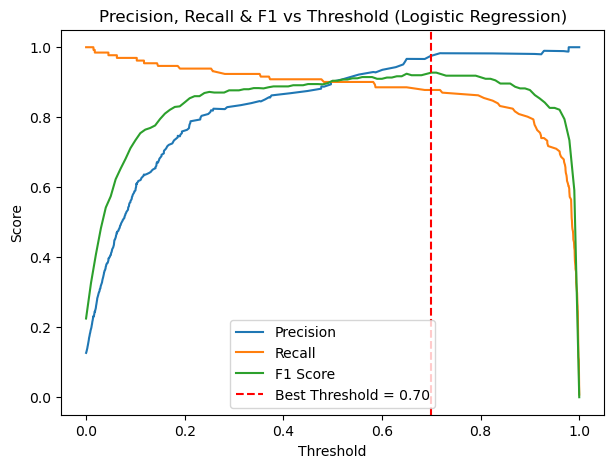

In [ ]:
# LR
y_proba_lr = rs_lr.best_estimator_.predict_proba(x_test)[:, 1]

thresholds = np.arange(0, 1.01, 0.01)   # 0.00 to 1.00 in steps of 0.01
f1_scores_lr = []

for t in thresholds:
    y_pred_lr = (y_proba_lr >= t).astype(int)
    f1_scores_lr.append(f1_score(y_test, y_pred_lr))
    
best_t_lr = thresholds[np.argmax(f1_scores_lr)]
best_f1_lr = max(f1_scores_lr)

print(f"Best Threshold lr: {best_t_lr:.2f}, Best F1 lr: {best_f1_lr:.4f}")

# precision-recall curve from sklearn
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(7,5))
plt.plot(pr_thresholds, precisions[:-1], label="Precision")
plt.plot(pr_thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores_lr, label="F1 Score")
plt.axvline(best_t_lr, color='r', linestyle='--', label=f"Best Threshold = {best_t_lr:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall & F1 vs Threshold (Logistic Regression)")
plt.legend()
plt.show()


In [ ]:
#SVC
y_score_svc = rs_svc.best_estimator_.decision_function(x_test)

thresholds = np.linspace(y_score_svc.min(), y_score_svc.max(), 100)
f1_scores_svc = []

for t in thresholds:
    y_pred_svc = (y_score_svc>= t).astype(int)
    f1_scores_svc.append(f1_score(y_test, y_pred_svc))

best_t_svc = thresholds[np.argmax(f1_scores_svc)]
best_f1_svc = max(f1_scores_svc)

print(f"Best Threshold SVC: {best_t_svc:.2f}, Best F1 SVC: {best_f1_svc:.4f}")


Best Threshold SVC: -0.02, Best F1 SVC: 0.9355


In [ ]:
# NB
y_proba_nb = rs_nb.best_estimator_.predict_proba(x_test)[:, 1]

thresholds = np.arange(0, 1.01, 0.01)   # 0.00 to 1.00 in steps of 0.01
f1_scores_nb = []

for t in thresholds:
    y_pred_nb = (y_proba_nb >= t).astype(int)
    f1_scores_nb.append(f1_score(y_test, y_pred_nb))
    
best_t_nb = thresholds[np.argmax(f1_scores_nb)]
best_f1_nb = max(f1_scores_nb)

print(f"Best Threshold nb: {best_t_nb:.2f}, Best F1 nb: {best_f1_nb:.4f}")


Best Threshold nb: 0.47, Best F1 nb: 0.9187


In [ ]:
# BRF
y_proba_brf = rs_brf.best_estimator_.predict_proba(x_test)[:, 1]

thresholds = np.arange(0, 1.01, 0.01)   # 0.00 to 1.00 in steps of 0.01
f1_scores_brf = []

for t in thresholds:
    y_pred_brf = (y_proba_brf >= t).astype(int)
    f1_scores_brf.append(f1_score(y_test, y_pred_brf))
    
best_t_brf= thresholds[np.argmax(f1_scores_brf)]
best_f1_brf = max(f1_scores_brf)

print(f"Best Threshold brf: {best_t_brf:.2f}, Best F1 brf: {best_f1_brf:.4f}")

Best Threshold brf: 0.60, Best F1 brf: 0.9157


In [ ]:
#integrating the best threshold-

In [ ]:
#LR

y_proba_lr = rs_lr.best_estimator_.predict_proba(x_test)[:, 1]

# Apply best threshold (say best_t_lr)
y_pred_lr = (y_proba_lr >= best_t_lr).astype(int)

f1_score_lr=f1_score(y_test, y_pred_lr)
precision_score_lr=precision_score(y_test, y_pred_lr)
recall_score_lr=recall_score(y_test, y_pred_lr)

# Evaluate again
print("F1:", f1_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

F1: 0.9274193548387096
Precision: 0.9829059829059829
Recall: 0.8778625954198473


In [ ]:
#SVC
y_scores_svc = rs_svc.best_estimator_.decision_function(x_test)

# Apply best threshold (say best_t_svc)
y_pred_svc = (y_scores_svc >= best_t_svc).astype(int)

f1_score_svc=f1_score(y_test, y_pred_svc)
precision_score_svc=precision_score(y_test, y_pred_svc)
recall_score_svc=recall_score(y_test, y_pred_svc)

# Evaluate again
print("F1:", f1_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall:", recall_score(y_test, y_pred_svc))

F1: 0.9354838709677419
Precision: 0.9914529914529915
Recall: 0.8854961832061069


In [ ]:
#NB
y_proba_nb = rs_nb.best_estimator_.predict_proba(x_test)[:, 1]

y_pred_nb = (y_proba_nb >= best_t_nb).astype(int)

f1_score_nb=f1_score(y_test, y_pred_nb)
precision_score_nb=precision_score(y_test, y_pred_nb)
recall_score_nb=recall_score(y_test, y_pred_nb)

print("F1:", f1_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))

F1: 0.9186991869918699
Precision: 0.9826086956521739
Recall: 0.8625954198473282


In [ ]:
#BRF
y_proba_brf = rs_brf.best_estimator_.predict_proba(x_test)[:, 1]

y_pred_brf = (y_proba_brf >= best_t_brf).astype(int)

f1_score_brf=f1_score(y_test, y_pred_brf)
precision_score_brf=precision_score(y_test, y_pred_brf)
recall_score_brf=recall_score(y_test, y_pred_brf)

print("F1:", f1_score(y_test, y_pred_brf))
print("Precision:", precision_score(y_test, y_pred_brf))
print("Recall:", recall_score(y_test, y_pred_brf))

F1: 0.9156626506024096
Precision: 0.9661016949152542
Recall: 0.8702290076335878


In [ ]:
model=['Logistic regression','Support Vector','Naive Bayes','Balanced Random Forest']
f1_score=[f1_score_lr,f1_score_svc,f1_score_nb,f1_score_brf]
precision_score=[precision_score_lr,precision_score_svc,precision_score_nb,precision_score_brf]
recall_score=[recall_score_lr,recall_score_svc,recall_score_nb,recall_score_brf]

final_performance=pd.DataFrame({'Model':model,'f1_score':f1_score,'precision_score':precision_score,'recall_score':recall_score})

In [ ]:
final_performance.sort_values('f1_score',ascending=False)

,Model,f1_score,precision_score,recall_score
1,Support Vector,0.935484,0.991453,0.885496
0,Logistic regression,0.927419,0.982906,0.877863
2,Naive Bayes,0.918699,0.982609,0.862595
3,Balanced Random Forest,0.915663,0.966102,0.870229


In [ ]:
#Ensemble can improve the results?

In [157]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Create Voting Classifier with all best models
voting_clf = VotingClassifier(estimators=[('lr', rs_lr.best_estimator_),('svc', rs_svc.best_estimator_),('nb', rs_nb.best_estimator_),('brf', rs_brf.best_estimator_)])

voting_clf.fit(x_train, y_train)

y_pred_vote=voting_clf.predict(x_test)

f1_score_vote=f1_score(y_test, y_pred_vote)
precision_score_vote=precision_score(y_test, y_pred_vote)
recall_score_vote=recall_score(y_test, y_pred_vote)

# Metrics
print("Final F1:", f1_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall:", recall_score(y_test, y_pred_vote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_vote))

C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  wa

Final F1: 0.9397590361445783
Precision: 0.9915254237288136
Recall: 0.8931297709923665

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.99      0.89      0.94       131

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [158]:
#Voting improves the model

In [159]:
from sklearn.ensemble import StackingClassifier

In [160]:
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Create Voting Classifier with all best models
stacking_clf = StackingClassifier(estimators=[('lr', rs_lr.best_estimator_),('svc', rs_svc.best_estimator_),('nb', rs_nb.best_estimator_),('brf', rs_brf.best_estimator_)])

stacking_clf.fit(x_train, y_train)

y_pred_stack=stacking_clf.predict(x_test)

f1_score_stack=f1_score(y_test, y_pred_stack)
precision_score_stack=precision_score(y_test, y_pred_stack)
recall_score_stack=recall_score(y_test, y_pred_stack)

# Metrics
print("Final F1:", f1_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Priya Gupta\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  wa

Final F1: 0.9402390438247012
Precision: 0.9833333333333333
Recall: 0.9007633587786259

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       903
           1       0.98      0.90      0.94       131

    accuracy                           0.99      1034
   macro avg       0.98      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



Stacking improves the model results